In [106]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df = pd.read_csv('17_columns_we_want.csv')


In [107]:
df.head()

,state,collection_year,strain_category,isolation_source,new_isolation_source,serotype_categorized,strain
0,USA:VA,1979,0,NaN,Uncatagorized,other,1827-70
1,USA:NE,2006,0,NaN,Uncatagorized,missing,EC4009
2,USA:CA,2006,0,NaN,Uncatagorized,missing,EC4192
3,USA:WI,2006,0,NaN,Uncatagorized,missing,EC4084
4,USA:PA,2006,0,NaN,Uncatagorized,missing,EC4127


In [108]:
try:
    top_5_states = df['state'].value_counts().index[0:6].to_list()
    top_5_states.remove('uncategorized')
except:
    top_5_states = df['state'].value_counts().index[0:5]
top_5_states


['USA:CA', 'USA:PA', 'USA:TX', 'USA:VA', 'USA:WA']

In [109]:
df[(df['state'].isin(top_5_states)) & (df['collection_year'] != 'missing')].info()

<class 'pandas.core.frame.DataFrame'>
Index: 23935 entries, 0 to 122104
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   state                 23935 non-null  object
 1   collection_year       23935 non-null  object
 2   strain_category       23935 non-null  object
 3   isolation_source      23692 non-null  object
 4   new_isolation_source  23935 non-null  object
 5   serotype_categorized  23935 non-null  object
 6   strain                23935 non-null  object
dtypes: object(7)
memory usage: 1.5+ MB


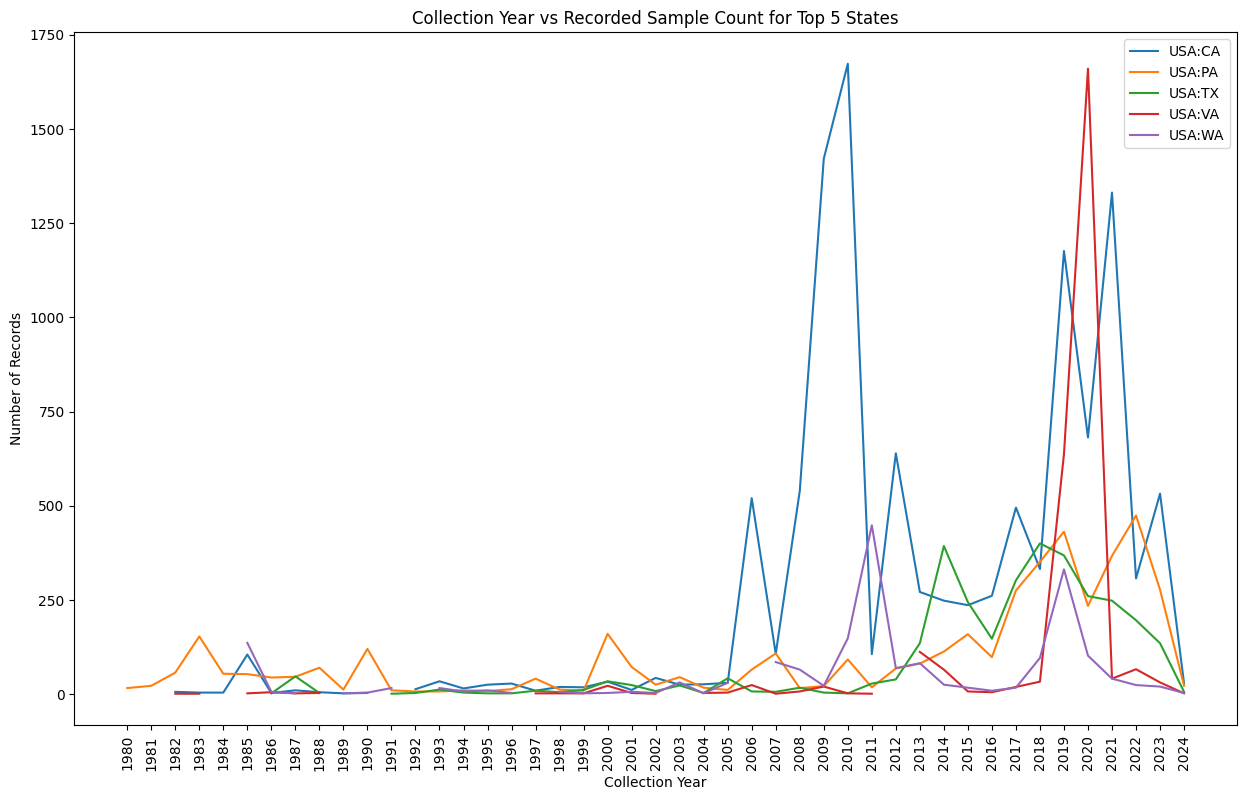

In [110]:
#line plots of collection_year vs. count
df_top_5 = df[df['state'].isin(top_5_states)]
df_top_5 = df_top_5[df_top_5['collection_year'] != 'missing']
df_top_5['collection_year'] = df_top_5['collection_year'].astype(int)
df_top_5 = df_top_5[df_top_5['collection_year'] > 1979]
df_top_5_gp = df_top_5.groupby(['state','collection_year']).size().unstack()
#for each state, make a line plot of collection_year vs number of records
plt.figure(figsize=(15,9))
for state in top_5_states:
    df_top_5_gp.loc[state].plot(label=state)
plt.legend()
plt.xlabel('Collection Year')
#xticks each year
plt.xticks(df_top_5_gp.columns, rotation=90)

plt.ylabel('Number of Records')
plt.title('Collection Year vs Recorded Sample Count for Top 5 States')
plt.show()




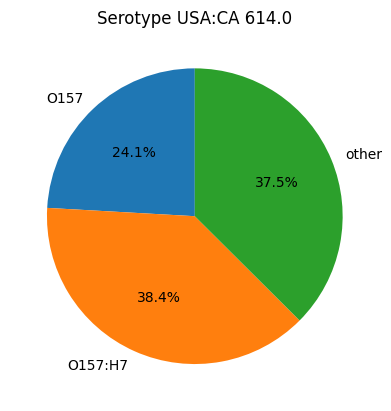

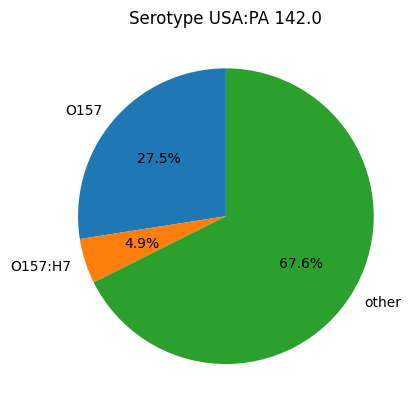

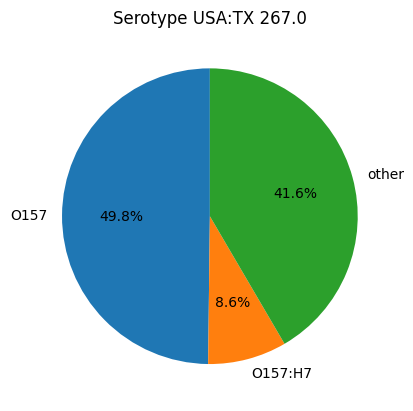

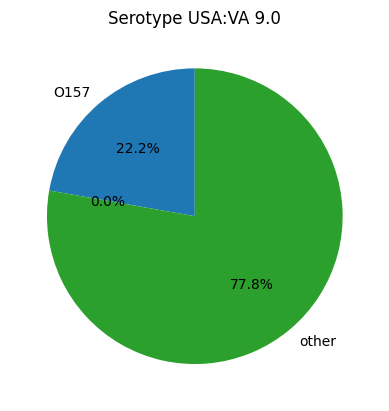

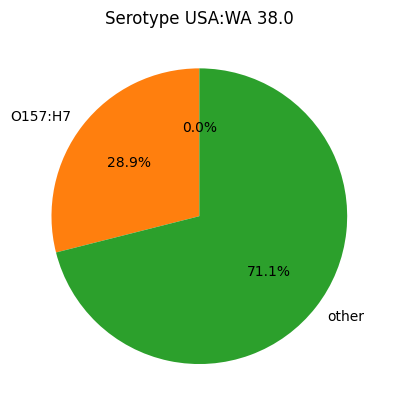

In [111]:
#Pie charts for serotype distribution
temp = df_top_5[df_top_5['serotype_categorized'] != 'missing']
df_top_5_serotype = temp.groupby(['state','serotype_categorized']).size().unstack()
df_top_5_serotype = df_top_5_serotype.fillna(0)
df_top_5_serotype['total'] = df_top_5_serotype.sum(axis=1)
df_top_5_serotype = df_top_5_serotype.sort_values('total', ascending=False)
df_top_5_serotype = df_top_5_serotype.drop(columns='total')
df_top_5_serotype = df_top_5_serotype.head(5)
#make a pie chart for each state
for state in top_5_states:
    df_top_5_serotype.loc[state].plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Serotype {state} {sum(df_top_5_serotype.loc[state])}')
    plt.ylabel('')
    plt.show()




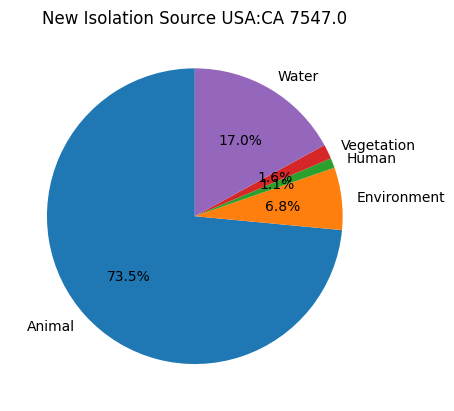

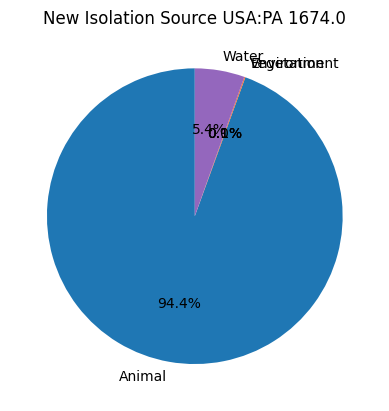

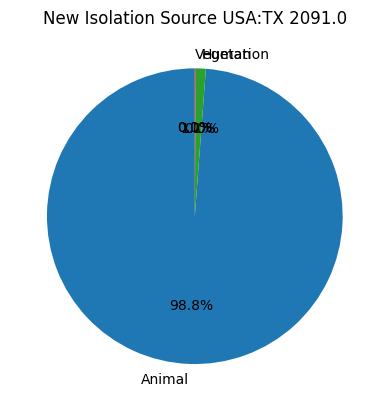

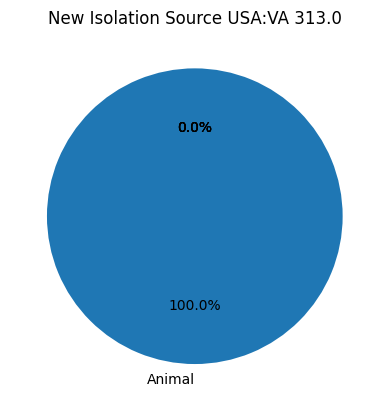

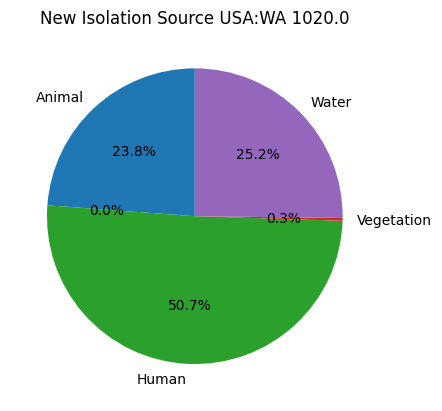

In [114]:
#Pie charts for categorized isolation source
temp = df_top_5[df_top_5['new_isolation_source'] != 'missing']
temp2 = temp[temp['new_isolation_source'] != 'Uncatagorized']
df_top_5_new_isolation_source = temp2.groupby(['state','new_isolation_source']).size().unstack()
df_top_5_new_isolation_source = df_top_5_new_isolation_source.fillna(0)
df_top_5_new_isolation_source['total'] = df_top_5_new_isolation_source.sum(axis=1)
df_top_5_new_isolation_source = df_top_5_new_isolation_source.sort_values('total', ascending=False)
df_top_5_new_isolation_source = df_top_5_new_isolation_source.drop(columns='total')
df_top_5_new_isolation_source = df_top_5_new_isolation_source.head(5)
for state in top_5_states:
    df_top_5_new_isolation_source.loc[state].plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'New Isolation Source {state} {sum(df_top_5_new_isolation_source.loc[state])}')
    plt.ylabel('')
    plt.show()
